In [ ]:
import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from torch import nn
import torchvision
from torchvision.transforms import ToTensor
import torch.optim as optim
from tqdm import tqdm
from torchvision import datasets, transforms

In [ ]:
!unzip RockPaper.zip

Archive:  RockPaper.zip
  inflating: README.dataset.txt      
  inflating: README.roboflow.txt     
  inflating: test/paper/paper-hires1_png.rf.bf14bb5fd86e4d28a00897e40459f192.jpg  
  inflating: test/paper/paper-hires2_png.rf.ce27ea20e90f7997bfde5cf953a5367f.jpg  
  inflating: test/paper/paper1_png.rf.6771d0803db4a4cb6e5e96339f785b9d.jpg  
  inflating: test/paper/paper2_png.rf.e48a2c38ee5c364493b26144d0d1b331.jpg  
  inflating: test/paper/paper3_png.rf.ddb6b703174cca92ceca42e995e5e25c.jpg  
  inflating: test/paper/paper4_png.rf.8206205dc26a062ddd14c16fb7bc54d4.jpg  
  inflating: test/paper/paper5_png.rf.7c669f01368a09cd3dad3ab605b1ee86.jpg  
  inflating: test/paper/paper6_png.rf.cd93026d24415813c3848b393e241e08.jpg  
  inflating: test/paper/paper7_png.rf.90da279cebef924d72317b24debd44fb.jpg  
  inflating: test/paper/paper8_png.rf.452a40f1ed9e3be1e2164f14d6106f33.jpg  
  inflating: test/paper/paper9_png.rf.db6fe38576ba4d5db891386b65e07cb1.jpg  
  inflating: test/rock/rock-hires1_png.rf

In [ ]:
train_dir='/content/train'
test_dir='/content/test'
val_dir='/content/valid'

In [ ]:
from torchvision import datasets, transforms
data_transform = transforms.Compose([transforms.RandomRotation(10), transforms.ToTensor(), ])

train_data = datasets.ImageFolder(root = train_dir,transform=data_transform,target_transform= None)

test_data = datasets.ImageFolder(root = test_dir,transform=data_transform)

print(f"Train data:\n{train_data}\nTest data:\n{test_data}")

Train data:
Dataset ImageFolder
    Number of datapoints: 2520
    Root location: /content/train
    StandardTransform
Transform: Compose(
               RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
               ToTensor()
           )
Test data:
Dataset ImageFolder
    Number of datapoints: 33
    Root location: /content/test
    StandardTransform
Transform: Compose(
               RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
               ToTensor()
           )


In [ ]:
means, stds = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
image_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(means, stds),
    transforms.RandomAffine(0, shear=0.2),
    transforms.RandomAffine(0, scale=(0.8, 1.2)),
    transforms.RandomRotation(20),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.CenterCrop((224, 224)),
])
train_data = datasets.ImageFolder(root = train_dir, transform=image_transforms, target_transform = None)

test_data = datasets.ImageFolder(root = test_dir, transform=image_transforms)

valid_data = datasets.ImageFolder(root = val_dir, transform=image_transforms)

In [ ]:
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000,  ..., 2.2489, 2.2489, 0.0000],
          [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 0.0000],
          [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 0.0000],
          ...,
          [0.0000, 2.2318, 2.2318,  ..., 2.2489, 2.2489, 2.2489],
          [0.0000, 2.2318, 2.2318,  ..., 2.2489, 2.2489, 2.2489],
          [0.0000, 2.2318, 2.2318,  ..., 0.0000, 0.0000, 0.0000]],
 
         [[0.0000, 0.0000, 0.0000,  ..., 2.4286, 2.4286, 0.0000],
          [2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 0.0000],
          [2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 0.0000],
          ...,
          [0.0000, 2.4111, 2.4111,  ..., 2.4286, 2.4286, 2.4286],
          [0.0000, 2.4111, 2.4111,  ..., 2.4286, 2.4286, 2.4286],
          [0.0000, 2.4111, 2.4111,  ..., 0.0000, 0.0000, 0.0000]],
 
         [[0.0000, 0.0000, 0.0000,  ..., 2.6400, 2.6400, 0.0000],
          [2.6400, 2.6400, 2.6400,  ..., 2.6400, 2.6400, 0.0000],
          [2.6400, 2.6400, 2.6400,  ...,

In [ ]:
image.shape

torch.Size([3, 224, 224])

In [ ]:
print(f"Train data:{len(train_data)}\nTest data: {len(test_data)}\nValidation Data: {len(valid_data)}")

Train data:2520
Test data: 33
Validation Data: 372


Text(0.5, 1.0, '0')

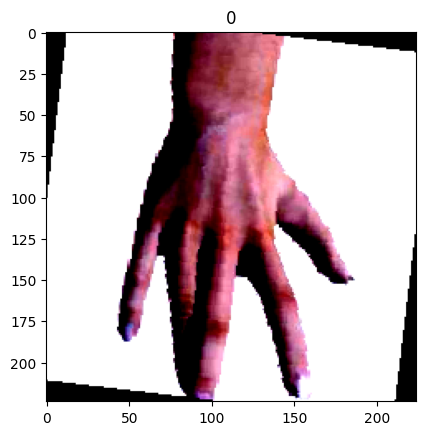

In [ ]:
image, label = train_data[0]
image = np.transpose(image, (1, 2, 0))
plt.imshow(image)
plt.title(label)

In [ ]:
class_names = train_data.classes
class_names

['paper', 'rock', 'scissors']

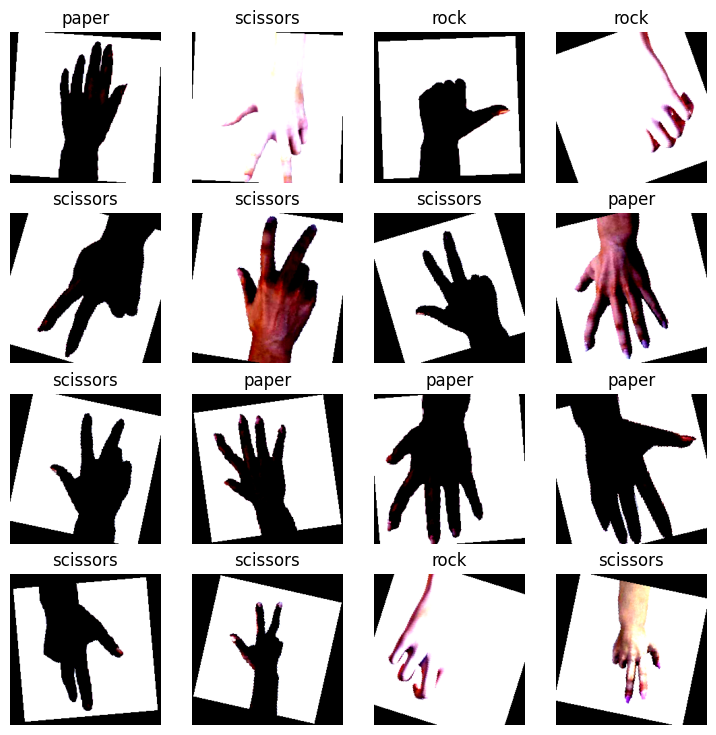

In [ ]:
torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(np.transpose(img, (1, 2, 0)))
    plt.title(class_names[label])
    plt.axis(False);

In [ ]:
from torch.utils.data import DataLoader

# Setup the batch size hyperparameter
BATCH_SIZE = 32

# Turn datasets into iterables (batches)
train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True # shuffle data every epoch?
)

valid_dataloader = DataLoader(valid_data, batch_size=BATCH_SIZE, shuffle=False # don't necessarily have to shuffle the testing data
)

test_dataloader = DataLoader(test_data, batch_size = BATCH_SIZE, shuffle = False)

# Let's check out what we've created
print(f"Dataloaders: {train_dataloader, valid_dataloader}")
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of validation dataloader: {len(valid_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x7c797e58ef20>, <torch.utils.data.dataloader.DataLoader object at 0x7c797e58c0a0>)
Length of train dataloader: 79 batches of 32
Length of validation dataloader: 12 batches of 32
Length of test dataloader: 2 batches of 32


In [ ]:
# Check out what's inside the training dataloader
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 3, 224, 224]), torch.Size([32]))

In [ ]:
class MyModel(nn.Module):
  def __init__(self):
    super(MyModel, self).__init__()
    self.net = net = nn.Sequential(
        nn.Conv2d(3, 32, kernel_size = 5, padding = 1),
        nn.ReLU(),
        nn.BatchNorm2d(32),
        nn.MaxPool2d(2,2),
        nn.Dropout(0.4),

        nn.Conv2d(32,64,kernel_size=5, padding=1),
        nn.ReLU(),
        nn.BatchNorm2d(64),
        nn.MaxPool2d(2,2),
        nn.Dropout(0.4),

        nn.Conv2d(64,64, kernel_size=5, padding=1),
        nn.ReLU(),
        nn.BatchNorm2d(64),
        nn.MaxPool2d(2,2),
        nn.Dropout(0.4),

        nn.Flatten(),
        nn.Dropout(0.4),

        nn.Linear(64*26*26, 512),
        nn.ReLU(),
        nn.Dropout(0.4),

        nn.Linear(512, 3)
    )

  def forward(self, x):
    return self.net(x)

model = MyModel()

In [ ]:
torch.manual_seed(42)

# Create sample batch of random numbers with same size as image batch
images = torch.randn(size=(32, 3, 300, 300)) # [batch_size, color_channels, height, width]
valid_image = images[0] # get a single image for testing
print(f"Image batch shape: {images.shape} -> [batch_size, color_channels, height, width]")
print(f"Single image shape: {valid_image.shape} -> [color_channels, height, width]")
print(f"Single image pixel values:\n{valid_image}")

Image batch shape: torch.Size([32, 3, 300, 300]) -> [batch_size, color_channels, height, width]
Single image shape: torch.Size([3, 300, 300]) -> [color_channels, height, width]
Single image pixel values:
tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  0.2539,  0.9364,  0.7122],
         [-0.0318,  0.1016,  1.3433,  ...,  0.3130,  0.8050, -1.1134],
         [ 0.4982, -1.2000,  0.1271,  ..., -0.3867,  0.9578, -0.8225],
         ...,
         [-1.7429, -1.2938, -0.6360,  ...,  1.2249,  0.6288,  0.9711],
         [ 0.0133,  0.0858,  1.2662,  ...,  0.5577,  0.6188,  0.9279],
         [ 0.4166,  1.5113, -0.9206,  ..., -0.3784,  0.5095,  1.1232]],

        [[-0.8472,  0.0580,  0.3687,  ..., -0.1233, -1.1663, -0.1329],
         [ 1.1337, -0.1207, -2.5940,  ..., -0.4396, -1.0556,  0.0393],
         [ 0.2506,  0.1506, -0.4333,  ...,  0.2672,  0.3675, -1.4014],
         ...,
         [ 0.1572, -0.1496,  1.6169,  ...,  0.7011, -0.8028,  2.1282],
         [ 1.6185, -0.4584,  0.9326,  ..., -0.4893, -0.1

In [ ]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
    train_loss, train_acc = 0, 0
    model.to(device)
    for batch, (X, y) in enumerate(data_loader):
        # Send data to GPU
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_true=y,
                                 y_pred=y_pred.argmax(dim=1)) # Go from logits -> pred labels

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

    # Calculate loss and accuracy per epoch and print out what's happening
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")

def valid_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
    valid_loss, valid_acc = 0, 0
    model.to(device)
    model.eval() # put model in eval mode
    # Turn on inference context manager
    with torch.inference_mode():
        for X, y in data_loader:
            # Send data to GPU
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            valid_pred = model(X)

            # 2. Calculate loss and accuracy
            valid_loss += loss_fn(valid_pred, y)
            valid_acc += accuracy_fn(y_true=y,
                y_pred=valid_pred.argmax(dim=1) # Go from logits -> pred labels
            )

        # Adjust metrics and print out
        valid_loss /= len(data_loader)
        valid_acc /= len(data_loader)
        print(f"Validation loss: {valid_loss:.5f} | Validation accuracy: {valid_acc:.2f}%\n")

In [ ]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
    acc = (correct / len(y_pred)) * 100
    return acc
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
torch.manual_seed(42)

# Measure time
from timeit import default_timer as timer
train_time_start_on_gpu = timer()

epochs = 10
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    train_step(data_loader=train_dataloader,
        model=model,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn
    )
    valid_step(data_loader=valid_dataloader,
        model=model,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn
    )

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 2.38048 | Train accuracy: 48.27%


 10%|█         | 1/10 [00:31<04:44, 31.66s/it]

Validation loss: 1.29919 | Validation accuracy: 44.79%

Epoch: 1
---------
Train loss: 0.59897 | Train accuracy: 76.67%


 20%|██        | 2/10 [01:00<04:02, 30.27s/it]

...

Validation loss: 0.75382 | Validation accuracy: 81.51%

Epoch: 8
---------
Train loss: 0.07189 | Train accuracy: 97.90%


 90%|█████████ | 9/10 [04:24<00:29, 29.23s/it]

Validation loss: 0.49517 | Validation accuracy: 85.99%

Epoch: 9
---------
Train loss: 0.06081 | Train accuracy: 98.29%


100%|██████████| 10/10 [04:54<00:00, 29.41s/it]

Validation loss: 0.54431 | Validation accuracy: 82.92%



In [ ]:
def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval() # put model in eval mode
    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            test_pred = model(X)
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))

        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")

# Assuming you have a test_dataloader
test_step(data_loader=test_dataloader,
          model=model,
          loss_fn=loss_fn,
          accuracy_fn=accuracy_fn)


Test loss: 0.29733 | Test accuracy: 95.31%



In [ ]:
import torchvision.models as models

googlenet = models.googlenet(pretrained=True)
num_features = googlenet.fc.in_features
googlenet.fc = nn.Identity()

custom_layers = nn.Sequential(
    nn.Linear(num_features, 1024),
    nn.ReLU(inplace=True),
    nn.Linear(1024, 512),
    nn.ReLU(inplace=True),
    nn.Linear(512, 3)
)

model_googlenet = nn.Sequential(googlenet, custom_layers)
print(model)


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=GoogLeNet_Weights.IMAGENET1K_V1`. You can also use `weights=GoogLeNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Sequential(
  (0): GoogLeNet(
    (conv1): BasicConv2d(
      (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
    (conv2): BasicConv2d(
      (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (conv3): BasicConv2d(
      (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
    (inception3a): Inception(
      (branch1): BasicConv2d(
        (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): Batc

In [ ]:
def train_fn(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []

    for epoch in range(num_epochs):
        model.train()
        running_train_loss = 0.0
        correct_train = 0
        total_train = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_loss = running_train_loss / len(train_loader)
        train_acc = 100 * correct_train / total_train
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # Evaluate the model on the validation set
        model.eval()
        running_val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                running_val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        val_loss = running_val_loss / len(val_loader)
        val_acc = 100 * correct_val / total_val
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(f'Epoch [{epoch+1}/{num_epochs}], '
              f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, '
              f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

    return train_losses, train_accs, val_losses, val_accs

In [ ]:
def test_fn(model, test_loader):
    correct = 0
    total = 0
    with torch.no_grad():
        model.eval()
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_accuracy = 100 * correct / total
    return test_accuracy

In [ ]:
custom_model = model.to(device)
googlenet_model = model_googlenet.to(device)

In [ ]:
loss = nn.CrossEntropyLoss()
optimizer_custom = torch.optim.Adam(custom_model.parameters(), lr=0.001)
optimizer_googlenet = torch.optim.Adam(googlenet_model.parameters(), lr=0.001)

In [ ]:
num_epochs = 10
train_losses_custom, train_accs_custom, val_losses_custom, val_accs_custom = train_fn(custom_model, train_dataloader, valid_dataloader, loss, optimizer_custom, num_epochs)
train_losses_googlenet, train_accs_googlenet, val_losses_googlenet, val_accs_googlenet = train_fn(googlenet_model, train_dataloader, valid_dataloader, loss, optimizer_googlenet, num_epochs)

Epoch [1/10], Train Loss: 0.1901, Train Acc: 93.57%, Val Loss: 0.0248, Val Acc: 99.73%
Epoch [2/10], Train Loss: 0.0412, Train Acc: 98.69%, Val Loss: 0.1080, Val Acc: 95.97%
Epoch [3/10], Train Loss: 0.0179, Train Acc: 99.48%, Val Loss: 0.0399, Val Acc: 98.39%
Epoch [4/10], Train Loss: 0.0003, Train Acc: 100.00%, Val Loss: 0.0267, Val Acc: 99.19%
Epoch [5/10], Train Loss: 0.0465, Train Acc: 98.57%, Val Loss: 0.0528, Val Acc: 97.31%
Epoch [6/10], Train Loss: 0.0740, Train Acc: 98.02%, Val Loss: 0.0519, Val Acc: 99.19%
Epoch [7/10], Train Loss: 0.0658, Train Acc: 98.06%, Val Loss: 0.3812, Val Acc: 85.75%
Epoch [8/10], Train Loss: 0.0219, Train Acc: 99.40%, Val Loss: 0.2704, Val Acc: 89.52%
Epoch [9/10], Train Loss: 0.0362, Train Acc: 99.21%, Val Loss: 0.0522, Val Acc: 97.31%
Epoch [10/10], Train Loss: 0.0070, Train Acc: 99.68%, Val Loss: 0.0316, Val Acc: 98.39%
Epoch [1/10], Train Loss: 0.1858, Train Acc: 93.17%, Val Loss: 0.1671, Val Acc: 94.89%
Epoch [2/10], Train Loss: 0.0404, Train A

In [ ]:
test_acc_custom = test_fn(custom_model, test_dataloader)
test_acc_googlenet = test_fn(googlenet_model, test_dataloader)
print("test accuracy for custom model",test_acc_custom)
print("test accuracy for googlenet",test_acc_googlenet)

test accuracy for custom model 100.0
test accuracy for googlenet 93.93939393939394


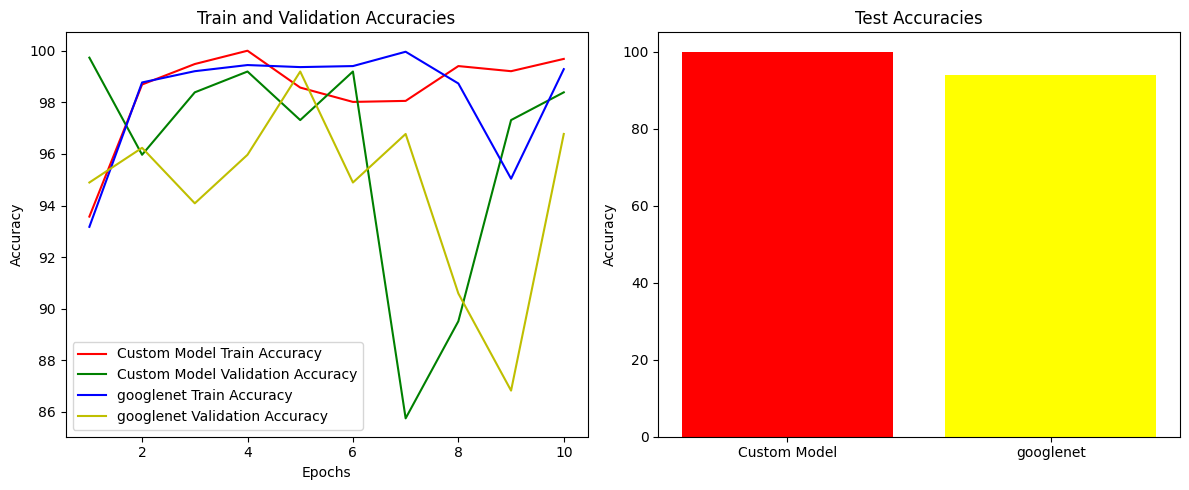

In [ ]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_accs_custom, 'r', label='Custom Model Train Accuracy')
plt.plot(epochs, val_accs_custom, 'g', label='Custom Model Validation Accuracy')
plt.plot(epochs, train_accs_googlenet, 'b', label='googlenet Train Accuracy')
plt.plot(epochs, val_accs_googlenet, 'y', label='googlenet Validation Accuracy')
plt.title('Train and Validation Accuracies')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.bar(['Custom Model', 'googlenet'], [test_acc_custom, test_acc_googlenet], color=['red', 'yellow'])
plt.title('Test Accuracies')
plt.ylabel('Accuracy')

plt.tight_layout()
plt.show()